# Parameters
## Main parameters

In [1]:
cell_type    = 'CD4'
learn_rate   = 1e-3
batch_size   = 32

## Additional parameters

In [2]:
data_dir         = "../data/"
results_dir      = "model"
max_epochs       = 20
model_patience   = 10
validating_frac  = 0.10
classify_layers  = []
encode_layers    = [128 , 32]
bottle_size      = 8
adj_class_weight = True

In [3]:
DE_output_dir = "DE_results"
data_output_dir = "data"
figure_output_dir = "figures"

# Load modules and define functions
## Imports

In [4]:
import os
import argparse
import itertools
import random
import seaborn as sns
import scanpy as sc
import scipy.sparse as sp

from sklearn.preprocessing import normalize
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc

import tensorflow as tf
import keras
from keras import optimizers
from keras.layers import Input, Dense, Reshape, Flatten, Dropout
from keras.models import Model
from keras.callbacks import EarlyStopping, LearningRateScheduler

import math
import numpy as np
import pandas as pd
import matplotlib
np.random.seed(42)
tf.random.set_seed(42)
matplotlib.use("Agg")
import matplotlib.pyplot as plt


I0000 00:00:1780767618.680997    9619 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780767618.683176    9619 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1780767618.750000    9619 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780767625.468940    9619 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

In [5]:
os.makedirs(results_dir, exist_ok=True)
os.makedirs(DE_output_dir, exist_ok=True)
os.makedirs(data_output_dir, exist_ok=True)
os.makedirs(figure_output_dir, exist_ok=True)

## Functions

### Plot classification function and save classification results

In [6]:
def plot_classification(m1, start, plot_path):
    # plot the training loss and accuracy
    end = len(m1.history['classification_accuracy'])
    N   = np.arange(start, end)
    s   = slice(start,end)

    plt.style.use("ggplot")
    plt.figure(figsize=(4, 3), dpi=300)

    plt.plot(N, (m1.history["classification_accuracy"][s]), label="train_accuracy")
    plt.plot(N, (m1.history["val_classification_accuracy"][s]), label="val_accuracy")

    plt.xlabel("Epoch #")
    plt.ylabel("Classification Accuracy")
    plt.legend()
    plt.subplots_adjust(left=0.25, right=0.98, top=0.98, bottom=0.2)
    plt.savefig(plot_path)
    plt.close()


def table_save_classification(m1, start, file_path):
    end = len(m1.history['classification_accuracy'])
    epochs = range(start, end)
    train_losses = m1.history['classification_accuracy'][start:end]
    val_losses = m1.history['val_classification_accuracy'][start:end]

    # Write the table to the file
    with open(file_path, 'w') as f:
        f.write("Epoch\tTrain_Acc\tVal_Acc\n")  # Header row
        for epoch, train_loss, val_loss in zip(epochs, train_losses, val_losses):
            f.write(f"{epoch}\t{train_loss:.4f}\t{val_loss:.4f}\n")


# Define model
## Model configuration

In [7]:
config = 'en_'
for size in encode_layers:
  config += str(size) + '_'

config += 'bn_' + str(bottle_size) + '_cl_'

for size in classify_layers:
  config += str(size) + '_'


config = config + 'bs_' + str(batch_size) + '_lr_' + str(learn_rate)
config = config + '_e_' + str(max_epochs)
config

'en_128_32_bn_8_cl_bs_32_lr_0.001_e_20'

## Read in data

In [8]:
adata = sc.read_h5ad(data_dir + cell_type + "_combined_filtered.h5ad")

print("Count Data:")
print(adata.X.shape)
print(adata.X[:5,:4])
print()
print("Meta Data:")
print(adata.obs.shape)
pd.set_option('display.max_columns', None)  # show all columns
print(adata.obs[:5])
print()

Count Data:
(390785, 6241)
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2 stored elements and shape (5, 4)>
  Coords	Values
  (2, 1)	1.0
  (4, 3)	1.0

Meta Data:
(390785, 44)
                                           study2  n_genes_by_counts  \
AGTGGGATCTGACCTC.58-THCA-Zheng_2021    Zheng_2021               1346   
CRC20-B-I_AACCGCGTCTGATACG-Chen_2024    Chen_2024               1029   
CRC04-B-II_ATTTCTGCAGTAAGCG-Chen_2024   Chen_2024               1236   
CGCTTCAAGGCAAAGA-1_PEM15C5-Chow_2023    Chow_2023                971   
P47-TCAGCTCGTTCAGCGC-1-Liu_2025          Liu_2025               1041   

                                       total_counts         TRB_cdr3  \
AGTGGGATCTGACCTC.58-THCA-Zheng_2021          3215.0  CA*MRGFIMATPSVR   
CRC20-B-I_AACCGCGTCTGATACG-Chen_2024         2930.0    CAAAATNNNEQFF   
CRC04-B-II_ATTTCTGCAGTAAGCG-Chen_2024        3943.0     CAAAGAGTEAFF   
CGCTTCAAGGCAAAGA-1_PEM15C5-Chow_2023         2697.0   CAAAGGPKSGELFF   
P47-TCAGCTCGTTC

In [9]:
depth_col = "total_counts"        # or your total count column
print("Depth Column:", depth_col)
print(adata.obs[depth_col].describe())

Depth Column: total_counts
count    390785.000000
mean       3769.267994
std        1724.321194
min         501.000000
25%        2609.000000
50%        3494.000000
75%        4568.000000
max       19996.000000
Name: total_counts, dtype: float64


In [10]:
from scipy.sparse import issparse
print("is sparse:", issparse(adata.X))

adata.layers["counts"] = adata.X.copy()

target_sum = 3000
d = adata.obs[depth_col].to_numpy()

scale = np.divide(target_sum, d, out=np.zeros_like(d, dtype=float), where=d>0)

if issparse(adata.X):
    X = adata.X.tocsr()
    adata.layers["norm"] = X.multiply(scale[:, None]).tocsr()
else:
    adata.layers["norm"] = adata.X * scale[:, None]

adata.X = adata.layers["norm"].copy()

sc.pp.log1p(adata)
print(adata.X.shape)
print(adata.X[:2, :4])

is sparse: True
(390785, 6241)
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 0 stored elements and shape (2, 4)>


### Prepare data splitting indices

In [11]:
print(adata.obs.shape)
print(adata.obs['study'].value_counts())

print(adata.obs["label"].value_counts())
print(pd.crosstab(adata.obs["study"], adata.obs["label"]))

train_indices, val_indices = train_test_split(np.arange(adata.n_obs), test_size=validating_frac, 
                                              stratify=adata.obs['study'], 
                                              random_state=42)
print("Length of train_indices:", len(train_indices))
print("Length of validation_indices:", len(val_indices))


(390785, 44)
study
Liu_2025      157105
Chen_2024     109721
Chow_2023      68222
Zheng_2021     33435
Liu_2022       22302
Name: count, dtype: int64
label
0    379381
1     11404
Name: count, dtype: int64
label            0     1
study                   
Chen_2024   109215   506
Chow_2023    68222     0
Liu_2022     20049  2253
Liu_2025    149733  7372
Zheng_2021   32162  1273
Length of train_indices: 351706
Length of validation_indices: 39079


### DE testing

In [12]:
adata.obs["label_cat"] = pd.Categorical(adata.obs["label"].astype(str),
                                        categories=["0", "1"])

# -----------------------------
# 1) Rank-sum DE: label==1 vs label==0
# -----------------------------
sc.tl.rank_genes_groups(
    adata,
    groupby="label_cat",
    groups=["1"],             # test group(s)
    reference="0",            # control group
    method="wilcoxon",
    corr_method="benjamini-hochberg",  # FDR
    use_raw=False,            # set True if you saved counts in .raw and want to test on raw
    n_genes=adata.n_vars, # compute stats for all genes
    key_added="de_wilcoxon"
)

# -----------------------------
# 2) Collect results into a DataFrame
# -----------------------------
# For Scanpy >=1.9:
df_de = sc.get.rank_genes_groups_df(adata, group="1", key="de_wilcoxon")
# Columns: ['names','scores','logfoldchanges','pvals','pvals_adj','pts','pts_rest']

# Sort by adjusted p-value (FDR)
# use kind='stable' to help keep the same way of breaking ties across different runs
df_de = df_de.sort_values("pvals_adj", ascending=True, kind='stable')

# Save full results and top 1000
df_de.to_csv(f"{DE_output_dir}/DE_{cell_type}.csv", index=False)


In [13]:
# -----------------------------
# 3) Volcano plot
# -----------------------------
df_de = pd.read_csv(f"{DE_output_dir}/DE_{cell_type}.csv")
x = df_de["logfoldchanges"]                 # log2FC in Scanpy is natural-log FC; if you prefer log2, convert:
# If you want true log2 fold-change:
# x = df_de["logfoldchanges"] / np.log(2)

y = -np.log10(df_de["pvals_adj"].clip(lower=1e-300))

plt.figure(figsize=(6,5), dpi=150)
plt.scatter(x, y, s=8, alpha=0.5)

# Highlight top 1000 by FDR
is_top = df_de.index.isin(df_de.index[:1000])
plt.scatter(x[is_top], y[is_top], s=10, alpha=0.8)

# Reference lines (optional)
plt.axhline(-np.log10(0.05), linestyle="--", linewidth=1)
plt.axvline(0, linestyle=":", linewidth=1)

plt.xlabel("log fold change (1 vs 0)")      # note: natural log by default
plt.ylabel("-log10(FDR)")
plt.title(f"Wilcoxon DE: {cell_type}")
plt.tight_layout()
plt.savefig(f"{figure_output_dir}/volcano_{cell_type}.png")
plt.close()


In [14]:
top_genes = df_de.sort_values("pvals", kind='stable').head(1000)["names"].tolist()
print(top_genes[:10])

# save the top 1000 genes to use for model training out
top_genes_file = f"{results_dir}/{cell_type}_top1000_genes.txt"
with open(top_genes_file, "w") as f:
    for g in top_genes:
        f.write(f"{g}\n")
print(f"\nSaved top1000 genes in the order used for model training to: {top_genes_file}")

adata_top1000 = adata[:, top_genes]
X = adata_top1000.X.toarray()
print(X.shape)
print(X[:2, :4])
print(adata_top1000.var_names[:11])

['DUSP4', 'CXCL13', 'GAPDH', 'NR3C1', 'SRGN', 'CTLA4', 'RGS1', 'TNFRSF18', 'HLA-A', 'RBPJ']

Saved top1000 genes in the order used for model training to: model/CD4_top1000_genes.txt
(390785, 1000)
[[0.         0.         1.05300523 0.        ]
 [0.         0.         0.70502179 0.        ]]
Index(['DUSP4', 'CXCL13', 'GAPDH', 'NR3C1', 'SRGN', 'CTLA4', 'RGS1',
       'TNFRSF18', 'HLA-A', 'RBPJ', 'BATF'],
      dtype='object')


In [15]:
# Split the data into training, validation, and testing sets
trainX = X[train_indices]
valX = X[val_indices]

trainY = adata.obs["label"][train_indices]
valY   = adata.obs["label"][val_indices]

print("Training Data:")
print(trainX.shape)
print(trainY.shape)
print()

print("Validation Data:")
print(valX.shape)
print(valY.shape)
print()

print('trainX[0:2, 0:4]:')
print(trainX[0:2, 0:4])
print()

print('trainY[0:2]:')
print(trainY[0:2])
print()

print('valX[0:2, 0:4]:')
print(valX[0:2, 0:4])
print()

print('valY[0:2]:')
print(valY[0:2])
print()


Training Data:
(351706, 1000)
(351706,)

Validation Data:
(39079, 1000)
(39079,)

trainX[0:2, 0:4]:
[[0.         0.         2.02423299 0.        ]
 [0.         0.         1.66849155 0.        ]]

trainY[0:2]:
CRC04-B-I_GTTACAGTCCAGTAGT-Chen_2024    0
CACACTCAGACCCACC-1_PEM13C1-Chow_2023    0
Name: label, dtype: int64

valX[0:2, 0:4]:
[[0.         0.         2.49266831 0.        ]
 [0.         0.         1.48141323 0.        ]]

valY[0:2]:
P204-TGTGGTAGTACACCGC-1-Liu_2025        0
CATGGCGTCCACGTTC-1_PEM12C5-Chow_2023    0
Name: label, dtype: int64



/loc/scratch/53001869/ipykernel_9619/3882201753.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  trainY = adata.obs["label"][train_indices]
/loc/scratch/53001869/ipykernel_9619/3882201753.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  valY   = adata.obs["label"][val_indices]


## Set up model

In [16]:
np.savetxt(f"{data_output_dir}/{cell_type}_valX.txt", valX, fmt="%.3e")
np.savetxt(f"{data_output_dir}/{cell_type}_valY.txt", valY, fmt="%d")

In [17]:
# Parameters
input_dim = trainX.shape[1]
encoding_dim = bottle_size  # Bottleneck layer size

# Input layer
input = Input(shape=(input_dim,))

# Encoder
encoded = Dense(encode_layers[0], activation='relu')(input)
for i in range(len(encode_layers)-1):
  encoded = Dense(encode_layers[i+1], activation='relu')(encoded)
bottleneck = Dense(encoding_dim, activation='relu')(encoded)  # Latent space (bottleneck)

# Decoder
decoded = Dense(32, activation='relu')(bottleneck)
decoded = Dense(128, activation='relu')(decoded)
decoded = Dense(input_dim, activation='relu', name='reconstruction')(decoded)  # Output layer (reconstructed input)

# Classification layer on top of the bottleneck
if len(classify_layers)==0:
  classifier_output = Dense(1, activation='sigmoid',name='classification')(bottleneck)
else:
  layer = Dense(size, activation='relu')(bottleneck)
  for i in range(len(classify_layers)-1):
    layer = Dense(classify_layers[i+1], activation='relu')(layer)
  classifier_output = Dense(1, activation='sigmoid',name='classification')(layer)

# Full model (Autoencoder + Classification)
full_model = Model(inputs = input, outputs = {"reconstruction": decoded, "classification": classifier_output})
full_model.summary()


E0000 00:00:1780769232.886046    9619 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1780769232.886578   14399 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1780769232.915593    9619 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 1000)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │    128,128 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      4,128 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 8)         │        264 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 32)        │        288 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128)       │      4,224 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ classification      │ (None, 1)         │          9 │ dense_2[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reconstruction      │ (None, 1000)      │    129,000 │ dense_4[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 266,041 (1.01 MB)

 Trainable params: 266,041 (1.01 MB)

 Non-trainable params: 0 (0.00 B)

# Train the model

In [18]:
reconstruction_weight = 1.0  # Weight for reconstruction loss
classification_weight = 1.0  # Weight for classification loss

In [19]:
# Compile the model
def scheduler(epoch, lr):
    if epoch < 10:
        return float(lr)
    else:
        return float(lr * tf.math.exp(-0.1))

lr_scheduler = LearningRateScheduler(scheduler)

adam1 = optimizers.Adam(learning_rate=learn_rate)

full_model.compile(
	optimizer=adam1,
	loss={'reconstruction':'mean_absolute_error',
	      'classification':'binary_crossentropy'},  # Two losses: MAE for reconstruction, BCE for classification
	metrics={'reconstruction': 'mean_absolute_error','classification': 'accuracy'}, 
	loss_weights = {
			 'reconstruction':reconstruction_weight,
			 'classification':classification_weight
             }
)

#early stopping
early_stopping = EarlyStopping(
    monitor='val_classification_accuracy',  # Metric to monitor
    patience=model_patience,                # Number of epochs to wait
    restore_best_weights=True, 
    mode='max'
)


In [20]:
trainY

CRC04-B-I_GTTACAGTCCAGTAGT-Chen_2024     0
CACACTCAGACCCACC-1_PEM13C1-Chow_2023     0
CRC25-B-I_ATCCACCTCGGAAACG-Chen_2024     0
CRC05-B-I_TATTACCTCAGCTCGG-Chen_2024     0
P592-GGAACTTTCTCCTATA-1-Liu_2025         0
                                        ..
CRC05-B-I_GCATACATCAAAGTAG-Chen_2024     0
CRC15-B-I_TTGGCAACATTCCTGC-Chen_2024     0
P93-ACGGGTCCACCCTATC-1-Liu_2025          0
CRC23-B-IV_TCCCGATGTCCAGTGC-Chen_2024    0
P395-ACTGAACAGGACAGAA-1-Liu_2025         0
Name: label, Length: 351706, dtype: int64

In [21]:

history = full_model.fit(
    x=trainX, 
    y={"reconstruction": trainX, "classification": trainY},
    epochs=max_epochs,
    batch_size=batch_size, 
    verbose=2,
    validation_data=(valX, {"reconstruction": valX, "classification": valY}),
    callbacks=[lr_scheduler, early_stopping]
)


Epoch 1/20
10991/10991 - 49s - 4ms/step - classification_accuracy: 0.9845 - classification_loss: 0.0414 - loss: 0.3397 - reconstruction_loss: 0.2983 - reconstruction_mean_absolute_error: 0.2983 - val_classification_accuracy: 0.9866 - val_classification_loss: 0.0352 - val_loss: 0.3225 - val_reconstruction_loss: 0.2874 - val_reconstruction_mean_absolute_error: 0.2874 - learning_rate: 0.0010
Epoch 2/20
10991/10991 - 47s - 4ms/step - classification_accuracy: 0.9872 - classification_loss: 0.0329 - loss: 0.3178 - reconstruction_loss: 0.2848 - reconstruction_mean_absolute_error: 0.2848 - val_classification_accuracy: 0.9874 - val_classification_loss: 0.0331 - val_loss: 0.3158 - val_reconstruction_loss: 0.2827 - val_reconstruction_mean_absolute_error: 0.2827 - learning_rate: 0.0010
Epoch 3/20
10991/10991 - 47s - 4ms/step - classification_accuracy: 0.9881 - classification_loss: 0.0302 - loss: 0.3095 - reconstruction_loss: 0.2793 - reconstruction_mean_absolute_error: 0.2793 - val_classification_a

In [22]:
full_model.save(f"{results_dir}/{cell_type}.keras")

In [23]:
name = cell_type
name += "_learn_rate_" + str(learn_rate)
name += "_batch_size_" + str(batch_size)
name += "_cla_weight_" + str(classification_weight)
name += "_rec_weight_" + str(reconstruction_weight)
if model_patience >= max_epochs:
  name += "_epochs_" + str(max_epochs)
else:
  name += "_max_epochs_" + str(max_epochs)

print(name)

path = os.path.join(results_dir, name)
if not os.path.exists(path):
  os.makedirs(path)


CD4_learn_rate_0.001_batch_size_32_cla_weight_1.0_rec_weight_1.0_max_epochs_20


In [24]:
print(valX.shape)
print(valX[:2, :4])

# Summarize the first and second columns
print("First column summary:")
print("  min:", np.min(valX[:, 0]))
print("  max:", np.max(valX[:, 0]))
print("  mean:", np.mean(valX[:, 0]))
print("  std:", np.std(valX[:, 0]))

print("Second column summary:")
print("  min:", np.min(valX[:, 1]))
print("  max:", np.max(valX[:, 1]))
print("  mean:", np.mean(valX[:, 1]))
print("  std:", np.std(valX[:, 1]))

(39079, 1000)
[[0.         0.         2.49266831 0.        ]
 [0.         0.         1.48141323 0.        ]]
First column summary:
  min: 0.0
  max: 3.4596204378268816
  mean: 0.29154640893622585
  std: 0.6062031029189263
Second column summary:
  min: 0.0
  max: 5.163824229886998
  mean: 0.07236615327627147
  std: 0.4363347831021923


In [25]:
prediction = full_model.predict(valX)["classification"].flatten()


1222/1222 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


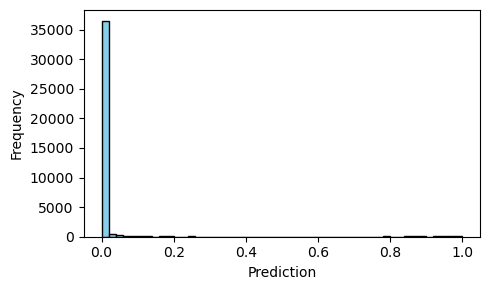

In [26]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 3))
plt.hist(prediction, bins=50, color='skyblue', edgecolor='black')
plt.xlabel('Prediction')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [27]:
plt.style.use("ggplot")
plt.figure(figsize=(4, 3), dpi=300)

plt.plot(history.history['reconstruction_loss'], label='Reconstruction (MAE)', color='tab:blue')
plt.plot(history.history['classification_loss'], label='Classification (BCE)', color='tab:orange')

plt.xlabel("Epoch #")
plt.ylabel("Loss")
plt.legend()
plt.subplots_adjust(left=0.2, right=0.98, top=0.98, bottom=0.2)
plt.savefig(f"{path}/classification_loss_plot.png")
plt.close()

plt.style.use("ggplot")
plt.figure(figsize=(4, 3), dpi=300)
plt.plot(history.history['val_reconstruction_loss'], label='Reconstruction (MAE)', color='tab:blue')
plt.plot(history.history['val_classification_loss'], label='Classification (BCE)', color='tab:orange')

plt.xlabel("Epoch #")
plt.ylabel("Loss")
plt.legend()
plt.subplots_adjust(left=0.2, right=0.98, top=0.98, bottom=0.2)
plt.savefig(f"{path}/val_classification_loss_plot.png")
plt.close()

plot_classification(history, 1, f"{path}/classification_accuracy_plot.png")
table_save_classification(history, 1, f"{path}/classification_accuracy_table.txt")
